# Patient Correlation Network: Temporal Evolution of Inter-Patient Distances

Compute pairwise $\|x_i - x_j\|_{L^2}$ distance matrices between patients' glucose
curves at each time window and fit a temporal Gaussian mixture model (MMD-based) to
capture how patient-to-patient relationships evolve over the study.

**Pipeline:**
1. Load CGM data, compute per-patient sliding-window average curves $x_i(t) \in L^2(0,24\text{h})$
2. Identify common patients, build symmetric distance matrix $D(t) \in \mathrm{Sym}(N)$ at each window
3. Project to $\mathrm{Sym}(N)$ coefficients via `SymmetricMatrixBasis` (scaled vech + PCA)
4. Bin into temporal slices, fit temporal GMM with MMD
5. Plot cluster means (distance-matrix heatmaps) and $\pi(t)$
6. NetworkX patient similarity graphs at 4 timesteps

In [1]:
import os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial.distance import pdist, squareform

sys.path.insert(0, os.path.abspath(".."))

from examples.train_glucodensity_temporal import (
    CONTROL_IDS, TREATMENT_IDS, load_and_preprocess_cgm,
    run_experiment, interpolate_pi,
)
from examples.train_glucodensity_correlation import (
    build_temporal_coefficients, estimate_sigma_median_heuristic,
)
from src import GaussianKernel, SymmetricMatrixBasis
from src.spaces import L2CosineBasis, H1CosineBasis   # L² and H¹ curve metrics
from src.temporal_mixture import (
    BasisLogitsTimeWeights, NeuralODETimeWeights,
)

/home/dani/projects/mixture/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---- Configuration ----
WINDOW_SIZE = 21
STRIDE = 1
MIN_PATIENT_PRESENCE = 0.4
N_TIME_BINS = 10
N_COMPONENTS = 3
R_PCA = 30                   # PCA truncation for Sym(N); None = full vech
EPOCHS = 1000
LR = 0.005
MODEL_TYPE = "basis"           # "basis" or "ode"
R_PI = 3
ODE_HIDDEN = 16
SIGMA_MULT = 4.0
SEED = 42
DATA_PATH = "../data/glucodensities/cgm_all_patients.csv"
EDGE_THRESHOLD_PERCENTILE = 2

# ---- Curve-space metric  ----------------------------------------
# "l2"  →  L²([0,24h])  standard norm       ‖x_i − x_j‖²_L² = ∫|x_i−x_j|² ds
#           captures level / magnitude differences between curves
# "h1"  →  H¹([0,24h])  Sobolev norm        ‖x_i − x_j‖²_H¹ = ‖x_i−x_j‖²_L² + ‖x_i'−x_j'‖²_L²
#           additionally penalises slope / shape differences
SPACE_METRIC = "h1"          # ← change to "h1" to use the Sobolev metric
R_S          = 16            # number of cosine modes used for metric projection
# -----------------------------------------------------------------

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cpu")
dtype  = torch.float64

## 1. Load CGM data and compute per-patient sliding-window curves

In [3]:
patient_data = load_and_preprocess_cgm(csv_path=DATA_PATH, verbose=True)
print(f"\nPatients loaded: {len(patient_data)}")

# Per-patient sliding-window average curves
N_SLOTS = 288
patient_window_curves = {}   # pid -> {w: avg_curve(288,)}

for pid, days_matrix in patient_data.items():
    n_days = days_matrix.shape[0]
    pw = {}
    for w in range(0, n_days - WINDOW_SIZE + 1, STRIDE):
        window = days_matrix[w:w + WINDOW_SIZE]
        avg_curve = np.nanmean(window, axis=0)
        nan_mask = np.isnan(avg_curve)
        if nan_mask.all():
            continue
        if nan_mask.any():
            valid_idx = np.where(~nan_mask)[0]
            avg_curve = np.interp(np.arange(N_SLOTS), valid_idx, avg_curve[valid_idx])
        pw[w] = avg_curve
    if pw:
        patient_window_curves[pid] = pw

n_win = [len(v) for v in patient_window_curves.values()]
print(f"Patients with valid windows: {len(patient_window_curves)}")
print(f"Windows per patient: min={min(n_win)}, max={max(n_win)}, median={int(np.median(n_win))}")

  Total days: 23760 → after rule 1 (prop_missing ≤ 0.2): 22772
  After value clipping & patient block filter: 22771 days, 98 patients
  Patients removed: 1

Patients loaded: 98
Patients with valid windows: 95
Windows per patient: min=26, max=345, median=231


## 2. Identify common patients and compute pairwise distance matrices

Distance metric is controlled by `SPACE_METRIC` in the config cell (`"l2"` or `"h1"`).  
Euclidean distance in the basis-coefficient space is isometric to the chosen Hilbert-space norm.

In [4]:
# All window positions across patients
all_w = set()
for pw in patient_window_curves.values():
    all_w.update(pw.keys())
all_w = sorted(all_w)

# Patients present at each position
w_pids = {w: set() for w in all_w}
for pid, pw in patient_window_curves.items():
    for w in pw:
        w_pids[w].add(pid)

# Common patients: present in >= MIN_PATIENT_PRESENCE of all positions
n_total_w    = len(all_w)
patient_pres = {pid: sum(1 for w in all_w if pid in w_pids[w]) / n_total_w
                for pid in patient_window_curves}
common_pids  = sorted(pid for pid, f in patient_pres.items() if f >= MIN_PATIENT_PRESENCE)
N_pat        = len(common_pids)
pid_to_idx   = {pid: i for i, pid in enumerate(common_pids)}

# Valid windows: positions where ALL common patients are present
valid_w = [w for w in all_w if all(pid in w_pids[w] for pid in common_pids)]

ctrl_set, treat_set = set(CONTROL_IDS), set(TREATMENT_IDS)
n_ctrl  = sum(1 for p in common_pids if p in ctrl_set)
n_treat = sum(1 for p in common_pids if p in treat_set)
print(f"Common patients (>={MIN_PATIENT_PRESENCE:.0%} presence): {N_pat}  "
      f"(Control: {n_ctrl}, Treatment: {n_treat})")
print(f"Valid windows (all common present): {len(valid_w)} / {len(all_w)}")

# ---- Build the chosen curve-metric basis  -------------------------
_basis_cls   = L2CosineBasis if SPACE_METRIC == "l2" else H1CosineBasis
_curve_basis = _basis_cls(T=1.0, R=R_S, grid_size=N_SLOTS, d=1, device=device, dtype=dtype)
print(f"\nCurve metric : {SPACE_METRIC.upper()}  (R_S={R_S} cosine modes)")

# ---- Compute raw pairwise distances  ------------------------------
t_indices     = np.array([w + (WINDOW_SIZE - 1) / 2.0 for w in valid_w])
dist_matrices = np.zeros((len(valid_w), N_pat, N_pat))

for idx, w in enumerate(valid_w):
    curves_raw = np.stack([patient_window_curves[pid][w] for pid in common_pids])
    curves_t   = torch.tensor(curves_raw, device=device, dtype=dtype).unsqueeze(-1)
    with torch.no_grad():
        coeffs = _curve_basis.project(curves_t).cpu().numpy()
    dist_matrices[idx] = squareform(pdist(coeffs, metric="euclidean"))

# ---- Normalise to similarity in [0, 1]  ---------------------------
# sim[i,j] = 1  ->  identical curves  (d = 0)
# sim[i,j] = 0  ->  maximally different (d = global max)
_d_global_max = dist_matrices.max()
dist_matrices = 1.0 - dist_matrices / (_d_global_max + 1e-10)
# diagonal stays 1 because d[i,i] = 0

off_diag = dist_matrices[dist_matrices < 1.0]
print(f"\nSimilarity matrices : {dist_matrices.shape}")
print(f"Similarity stats    : min={off_diag.min():.3f}, "
      f"median={np.median(off_diag):.3f}, max={off_diag.max():.3f}")


Common patients (>=40% presence): 76  (Control: 25, Treatment: 51)
Valid windows (all common present): 141 / 345

Curve metric : H1  (R_S=16 cosine modes)

Similarity matrices : (141, 76, 76)
Similarity stats    : min=0.000, median=0.582, max=0.909


## 3. Project to Sym(N), temporal binning, and fit temporal GMM

In [5]:
# Project distance matrices to Sym(N) coefficients
dist_t = torch.tensor(dist_matrices, device=device, dtype=dtype)

if R_PCA is not None:
    basis = SymmetricMatrixBasis.from_data(
        n=N_pat, R=R_PCA, training_matrices=dist_t, device=device, dtype=dtype)
    print(f"PCA truncation: {basis.full_dim} -> {basis.coeff_dim}")
else:
    basis = SymmetricMatrixBasis(n=N_pat, device=device, dtype=dtype)
    print(f"Full vech: coeff_dim = {basis.coeff_dim}")

coeffs_all = basis.project(dist_t).detach().cpu().numpy()
print(f"Projected coefficient shape: {coeffs_all.shape}")

PCA truncation: 2926 -> 30
Projected coefficient shape: (141, 30)


In [6]:
# Temporal binning
rep = build_temporal_coefficients(
    coeffs=coeffs_all, t_indices=t_indices, n_time_bins=N_TIME_BINS,
    device=device, dtype=dtype, verbose=True,
)
X_time, t_grid, mask = rep["X_time"], rep["t_grid"], rep["mask"]

# Kernel bandwidth (median heuristic)
sigma_auto = estimate_sigma_median_heuristic(X_time, mask)
sigma = max(1e-8, sigma_auto * SIGMA_MULT)
print(f"Kernel sigma: auto={sigma_auto:.4f}, final={sigma:.4f}")
kernel = GaussianKernel(sigma=sigma)

  Temporal binning: 10 requested, 10 non-empty
  Day range: [10.0, 150.0]
  Bin sizes: min=14, max=15, median=14
  Padded to n_max=15, coeff_dim=30
Kernel sigma: auto=7.7595, final=31.0379


In [7]:
# Time-weight model
if MODEL_TYPE == "basis":
    time_basis = L2CosineBasis(
        T=1.0, R=R_PI, grid_size=rep["L_t"], d=1, device=device, dtype=dtype)
    twm = BasisLogitsTimeWeights(
        basis_matrix=time_basis.Phi, num_components=N_COMPONENTS,
        device=device, dtype=dtype)
    model_name = "PatientDistBasis"
else:
    twm = NeuralODETimeWeights(
        t_grid=t_grid, num_components=N_COMPONENTS,
        hidden_dim=ODE_HIDDEN, device=device, dtype=dtype)
    model_name = "PatientDistODE"

# Train
print(f"Training {model_name} ({EPOCHS} epochs)...")
model, history, pi_t = run_experiment(
    name=model_name, time_weight_model=twm, X_time=X_time,
    kernel=kernel, n_components=N_COMPONENTS, coeff_dim=rep["coeff_dim"],
    num_epochs=EPOCHS, lr=LR, device=device, dtype=dtype,
    mask=mask, verbose=True,
)

Training PatientDistBasis (1000 epochs)...


Epoch  125/1000: MMD²(avg_t) = 0.009933
Epoch  250/1000: MMD²(avg_t) = 0.008514
Epoch  375/1000: MMD²(avg_t) = 0.007984
Epoch  500/1000: MMD²(avg_t) = 0.007695
Epoch  625/1000: MMD²(avg_t) = 0.007507
Epoch  750/1000: MMD²(avg_t) = 0.007352
Epoch  875/1000: MMD²(avg_t) = 0.007016
Epoch 1000/1000: MMD²(avg_t) = 0.006733
PatientDistBasis final MMD²(avg_t): 0.006733
PatientDistBasis mean pi over t: [0.43492089 0.338552   0.22652711]


## 4. Plot: cluster means (distance-matrix heatmaps) and $\pi(t)$

/tmp/ipykernel_1653/2998453125.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


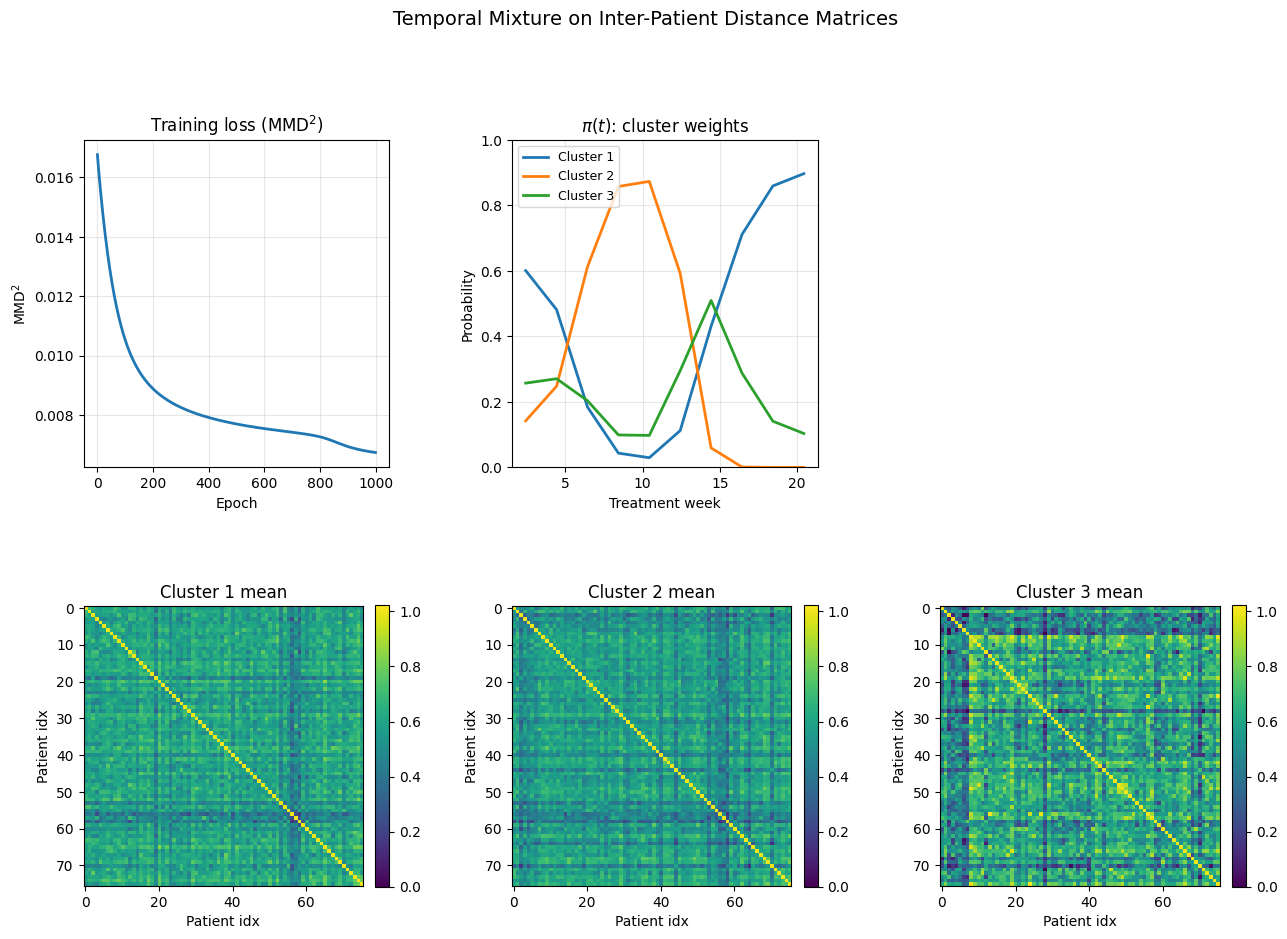

In [8]:
# Reconstruct cluster mean matrices
with torch.no_grad():
    means_coeff = model.mean.cpu()
means_orig = means_coeff * rep["coeff_std"].cpu() + rep["coeff_mean"].cpu()
recon_means = basis.reconstruct(means_orig)
recon_means_np = recon_means.detach().numpy()

pi_t_np = pi_t.cpu().numpy()
t_np = t_grid.detach().cpu().numpy()
day_range = rep["t_max_days"] - rep["t_min_days"]
t_days = t_np * day_range + rep["t_min_days"]
use_weeks = t_days.max() > 30
t_axis = t_days / 7.0 if use_weeks else t_days
t_label = "Treatment week" if use_weeks else "Treatment day"
K = N_COMPONENTS

fig = plt.figure(figsize=(5 * max(K, 2), 10))
gs = fig.add_gridspec(2, max(K, 2), hspace=0.35, wspace=0.4)

# Training loss
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(history, lw=2, color="tab:blue")
ax0.set_title("Training loss (MMD$^2$)")
ax0.set_xlabel("Epoch"); ax0.set_ylabel("MMD$^2$"); ax0.grid(alpha=0.3)

# pi(t)
ax1 = fig.add_subplot(gs[0, 1])
for k in range(K):
    ax1.plot(t_axis, pi_t_np[:, k], lw=2, label=f"Cluster {k+1}")
ax1.set_title(r"$\pi(t)$: cluster weights")
ax1.set_xlabel(t_label); ax1.set_ylabel("Probability")
ax1.set_ylim(0, 1); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# Mean distance matrices as heatmaps
vmax = np.abs(recon_means_np).max()
for k in range(K):
    ax = fig.add_subplot(gs[1, k])
    im = ax.imshow(recon_means_np[k], cmap="viridis", aspect="equal", vmin=0, vmax=vmax)
    ax.set_title(f"Cluster {k+1} mean")
    ax.set_xlabel("Patient idx"); ax.set_ylabel("Patient idx")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Temporal Mixture on Inter-Patient Distance Matrices", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Patient similarity network at 4 timesteps

Each node is a patient (blue = Control, red = Treatment).  
Edges connect patient pairs whose $L^2$ distance falls below a threshold.  
Edge colour encodes proximity: darker green = closer curves.

Similarity threshold (top 2% pairs): 0.769


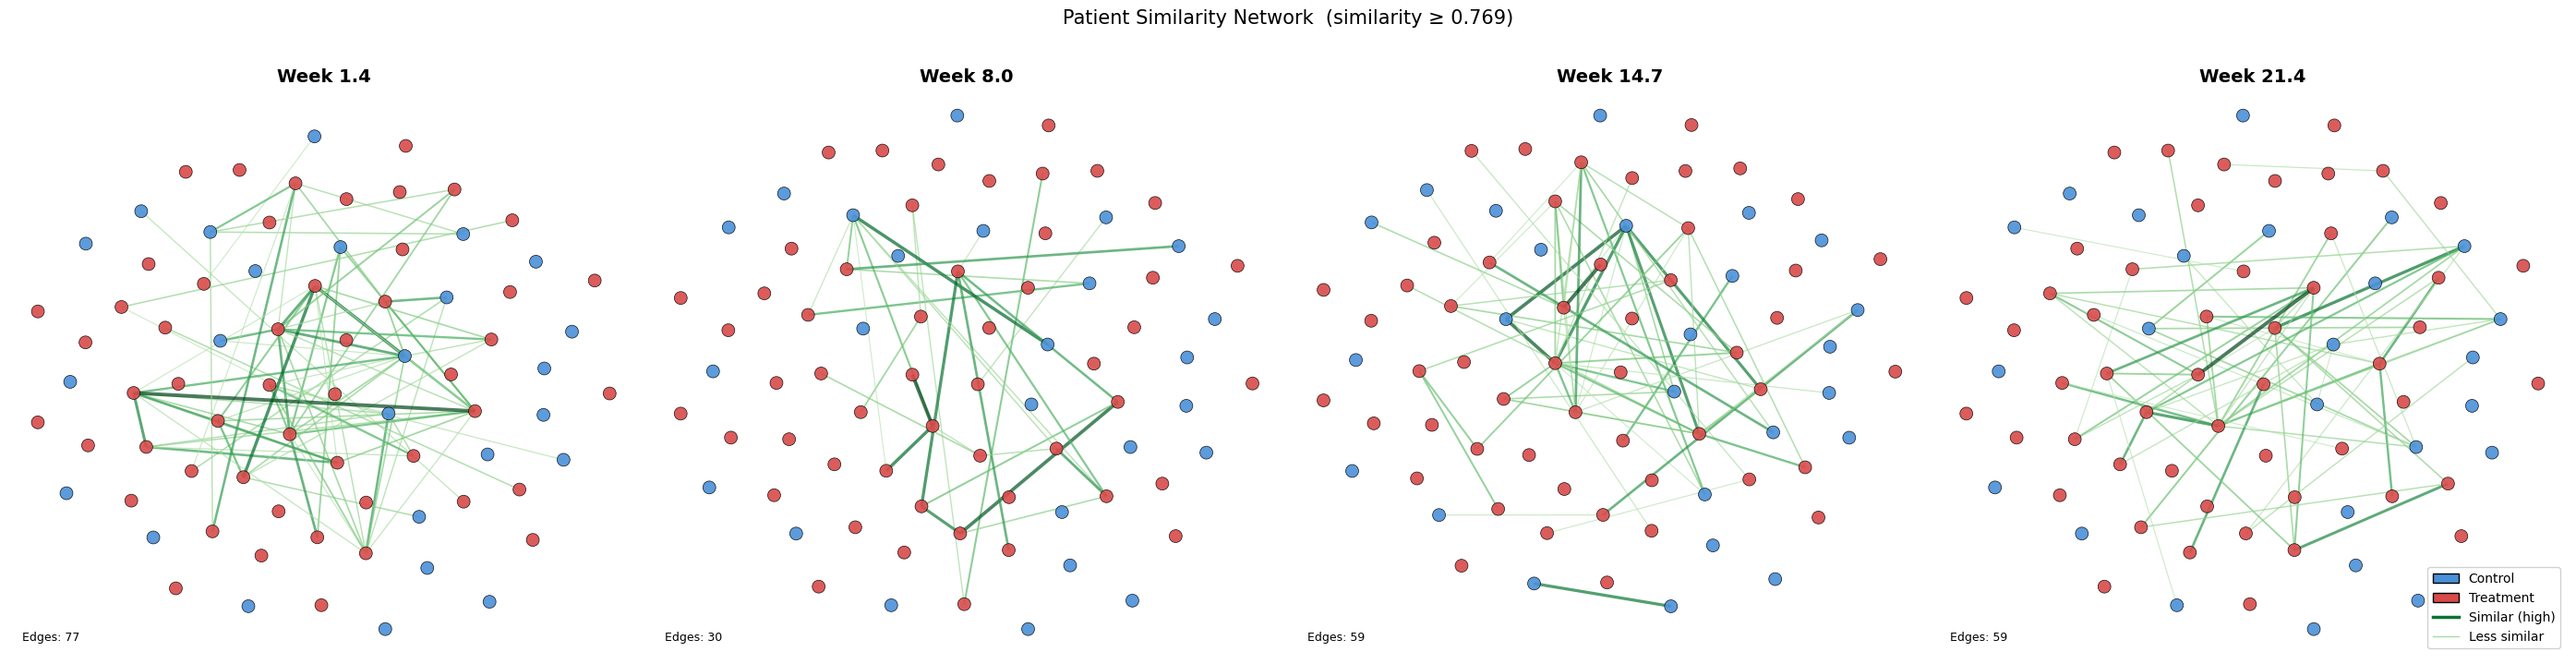

In [9]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

n_graph_times = 4
graph_indices = np.linspace(0, len(valid_w) - 1, n_graph_times, dtype=int)

# Node colours by group
node_colors = []
for pid in common_pids:
    if pid in ctrl_set:
        node_colors.append("#4A90D9")
    elif pid in treat_set:
        node_colors.append("#D94A4A")
    else:
        node_colors.append("#999999")

# Similarity threshold: keep top EDGE_THRESHOLD_PERCENTILE % most-similar pairs
off_diag  = dist_matrices[dist_matrices < 1.0]
threshold = np.percentile(off_diag, 100 - EDGE_THRESHOLD_PERCENTILE)
print(f"Similarity threshold (top {EDGE_THRESHOLD_PERCENTILE}% pairs): {threshold:.3f}")

# Stable layout from time-averaged similarity (diagonal zeroed so nx ignores self-loops)
avg_sim = dist_matrices.mean(axis=0).copy()
np.fill_diagonal(avg_sim, 0)
G_layout = nx.from_numpy_array(avg_sim)
pos = nx.spring_layout(G_layout, weight="weight", seed=SEED,
                       k=2.5 / np.sqrt(N_pat), iterations=200)

fig, axes = plt.subplots(1, n_graph_times, figsize=(7 * n_graph_times, 7))

for ax_idx, t_idx in enumerate(graph_indices):
    ax    = axes[ax_idx]
    S     = dist_matrices[t_idx]
    t_day = t_indices[t_idx]

    G = nx.Graph()
    G.add_nodes_from(range(N_pat))

    edges, edge_w = [], []
    for i in range(N_pat):
        for j in range(i + 1, N_pat):
            if S[i, j] >= threshold:          # high similarity = close
                G.add_edge(i, j)
                edges.append((i, j))
                edge_w.append(S[i, j])

    # Edge colour: higher similarity = darker green
    if edge_w:
        ew      = np.array(edge_w)
        ew_norm = (ew - ew.min()) / (ew.max() - ew.min() + 1e-9)
        edge_colors = [plt.cm.Greens(0.3 + 0.7 * v) for v in ew_norm]
        edge_widths = 0.8 + 2.0 * ew_norm
    else:
        edge_colors, edge_widths = [], []

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=100, alpha=0.9,
                           edgecolors="black", linewidths=0.5)
    if edges:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges,
                               edge_color=edge_colors, width=edge_widths,
                               alpha=0.7)

    title = f"Week {t_day / 7:.1f}" if use_weeks else f"Day {t_day:.0f}"
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_axis_off()
    ax.text(0.02, 0.02, f"Edges: {len(edges)}", transform=ax.transAxes,
            fontsize=9, va="bottom")

legend_elements = [
    Patch(facecolor="#4A90D9", edgecolor="black", label="Control"),
    Patch(facecolor="#D94A4A", edgecolor="black", label="Treatment"),
    Line2D([0], [0], color=plt.cm.Greens(0.85), lw=2.5, label="Similar (high)"),
    Line2D([0], [0], color=plt.cm.Greens(0.35), lw=1,   label="Less similar"),
]
axes[-1].legend(handles=legend_elements, loc="lower right", fontsize=10, framealpha=0.9)

fig.suptitle(f"Patient Similarity Network  (similarity \u2265 {threshold:.3f})",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


## 6. Patient similarity network with community-separated layout

Same 4 timesteps, but the two groups (Control / Treatment) are treated as known communities and placed in separate spatial clusters using a supergraph spring layout, making inter-group vs intra-group edges immediately visible.

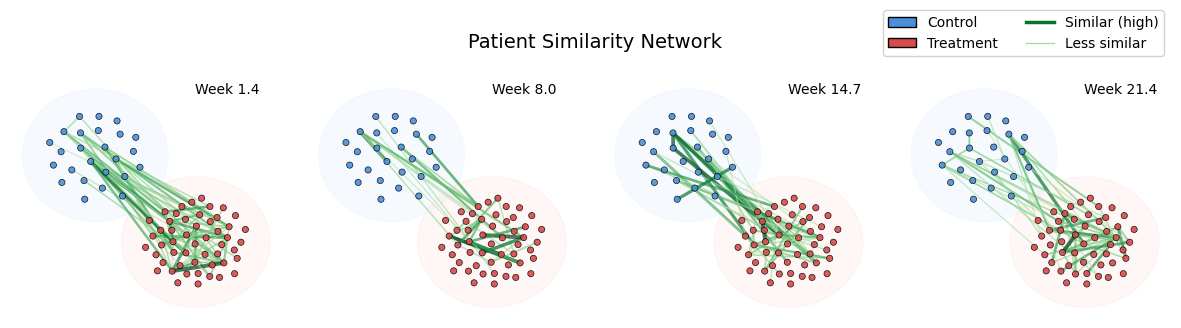

In [10]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
EDGE_THRESHOLD_PERCENTILE = 2

# ---- Build community-separated layout ----
ctrl_indices  = [pid_to_idx[p] for p in common_pids if p in ctrl_set]
treat_indices = [pid_to_idx[p] for p in common_pids if p in treat_set]
communities   = [ctrl_indices, treat_indices]

supergraph = nx.path_graph(2)
superpos   = nx.spring_layout(supergraph, scale=1, seed=SEED)
centers    = list(superpos.values())

# Time-averaged similarity as edge weights for internal layout
avg_sim = dist_matrices.mean(axis=0).copy()
np.fill_diagonal(avg_sim, 0)
G_full  = nx.from_numpy_array(avg_sim)

pos = {}
for center, comm in zip(centers, communities):
    subg = G_full.subgraph(comm)
    pos.update(nx.spring_layout(subg, center=center, seed=SEED,
                                weight="weight", k=1.5 / max(np.sqrt(len(comm)), 1)))

# ---- Node colours ----
node_colors = []
for pid in common_pids:
    if pid in ctrl_set:
        node_colors.append("#4A90D9")
    elif pid in treat_set:
        node_colors.append("#D94A4A")
    else:
        node_colors.append("#999999")

# ---- Similarity threshold ----
off_diag  = dist_matrices[dist_matrices < 1.0]
threshold = np.percentile(off_diag, 100 - EDGE_THRESHOLD_PERCENTILE)

# ---- Plot 4 timesteps ----
n_graph_times = 4
graph_indices = np.linspace(0, len(valid_w) - 1, n_graph_times, dtype=int)

fig, axes = plt.subplots(1, n_graph_times, figsize=(3 * n_graph_times, 3))

for ax_idx, t_idx in enumerate(graph_indices):
    ax    = axes[ax_idx]
    S     = dist_matrices[t_idx]
    t_day = t_indices[t_idx]

    G = nx.Graph()
    G.add_nodes_from(range(N_pat))

    edges, edge_w = [], []
    for i in range(N_pat):
        for j in range(i + 1, N_pat):
            if S[i, j] >= threshold:          # high similarity = close
                G.add_edge(i, j)
                edges.append((i, j))
                edge_w.append(S[i, j])

    # Edge colour: higher similarity = darker green
    if edge_w:
        ew      = np.array(edge_w)
        ew_norm = (ew - ew.min()) / (ew.max() - ew.min() + 1e-9)
        edge_colors = [plt.cm.Greens(0.3 + 0.7 * v) for v in ew_norm]
        edge_widths = 0.8 + 2.0 * ew_norm
    else:
        edge_colors, edge_widths = [], []

    for comm, bg_color in zip(communities, ("#DDEEFF", "#FFDDDD")):
        comm_pos = np.array([pos[n] for n in comm])
        cx, cy   = comm_pos.mean(axis=0)
        rx = comm_pos[:, 0].std() * 2.5 + 0.15
        ry = comm_pos[:, 1].std() * 2.5 + 0.15
        ellipse = plt.matplotlib.patches.Ellipse(
            (cx, cy), width=2 * rx, height=2 * ry,
            color=bg_color, alpha=0.25, zorder=0)
        ax.add_patch(ellipse)

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=20, alpha=0.9,
                           edgecolors="black", linewidths=0.5)
    if edges:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges,
                               edge_color=edge_colors, width=edge_widths,
                               alpha=0.7)

    title = f"Week {t_day / 7:.1f}" if use_weeks else f"Day {t_day:.0f}"
    ax.text(0.68, 0.98, title, transform=ax.transAxes, fontsize=10, va="top")
    ax.set_axis_off()

legend_elements = [
    Patch(facecolor="#4A90D9", edgecolor="black", label="Control"),
    Patch(facecolor="#D94A4A", edgecolor="black", label="Treatment"),
    Line2D([0], [0], color=plt.cm.Greens(0.85), lw=2.5, label="Similar (high)"),
    Line2D([0], [0], color=plt.cm.Greens(0.35), lw=1.0, label="Less similar"),
]

header_y = 1.0
fig.suptitle("Patient Similarity Network", fontsize=14, y=header_y)
fig.legend(handles=legend_elements,
           loc="center right",
           bbox_to_anchor=(0.98, header_y),
           fontsize=10, framealpha=0.9, ncols=2)

plt.tight_layout()
fig.subplots_adjust(top=0.85)
plt.show()


/tmp/ipykernel_1653/2412857122.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


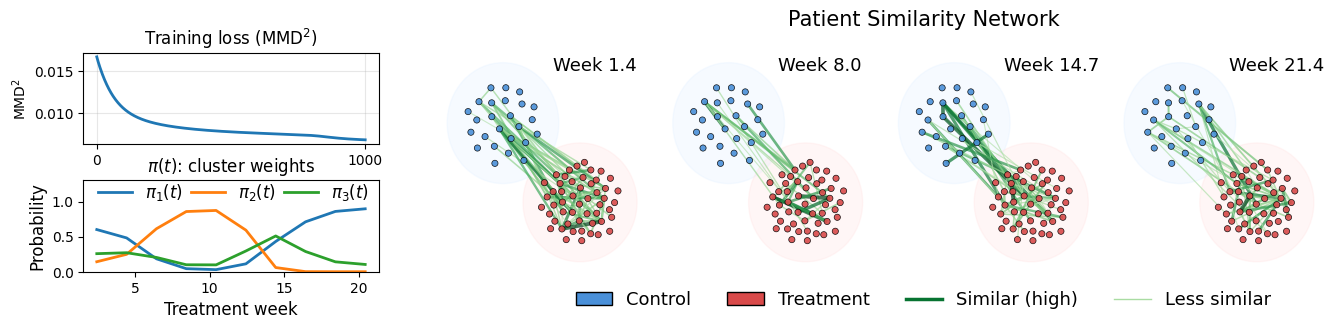

In [24]:
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse, Patch

if "pi_t_np" not in globals():
    pi_t_np = pi_t.cpu().numpy()
if "t_axis" not in globals() or "t_label" not in globals() or "use_weeks" not in globals():
    t_np = t_grid.detach().cpu().numpy()
    day_range = rep["t_max_days"] - rep["t_min_days"]
    t_days = t_np * day_range + rep["t_min_days"]
    use_weeks = t_days.max() > 30
    t_axis = t_days / 7.0 if use_weeks else t_days
    t_label = "Treatment week" if use_weeks else "Treatment day"
K = pi_t_np.shape[1]

edge_percentile = EDGE_THRESHOLD_PERCENTILE if "EDGE_THRESHOLD_PERCENTILE" in globals() else 2

ctrl_indices = [pid_to_idx[p] for p in common_pids if p in ctrl_set]
treat_indices = [pid_to_idx[p] for p in common_pids if p in treat_set]
communities = [ctrl_indices, treat_indices]

supergraph = nx.path_graph(2)
superpos = nx.spring_layout(supergraph, scale=1, seed=SEED)
centers = list(superpos.values())

avg_sim = dist_matrices.mean(axis=0).copy()
np.fill_diagonal(avg_sim, 0)
G_full = nx.from_numpy_array(avg_sim)

pos = {}
for center, comm in zip(centers, communities):
    subg = G_full.subgraph(comm)
    pos.update(
        nx.spring_layout(
            subg,
            center=center,
            seed=SEED,
            weight="weight",
            k=1.5 / max(np.sqrt(len(comm)), 1),
        )
    )

node_colors = []
for pid in common_pids:
    if pid in ctrl_set:
        node_colors.append("#4A90D9")
    elif pid in treat_set:
        node_colors.append("#D94A4A")
    else:
        node_colors.append("#999999")

off_diag = dist_matrices[dist_matrices < 1.0]
threshold = np.percentile(off_diag, 100 - edge_percentile)
n_graph_times = 4
graph_indices = np.linspace(0, len(valid_w) - 1, n_graph_times, dtype=int)

fig = plt.figure(figsize=(16, 3))
outer = fig.add_gridspec(2, 2, width_ratios=(1.0, 3.0), hspace=0.4, wspace=0.1)

ax_loss = fig.add_subplot(outer[0, 0])
ax_loss.plot(history, lw=2, color="tab:blue")
ax_loss.set_title("Training loss (MMD$^2$)")
#ax_loss.set_xlabel("Epoch")
ax_loss.set_xticks([0,1000])
ax_loss.set_ylabel("MMD$^2$")
ax_loss.grid(alpha=0.3)

ax_pi = fig.add_subplot(outer[1, 0])
for k in range(K):
    ax_pi.plot(t_axis, pi_t_np[:, k], lw=2, label=f"$\\pi_{{{k+1}}}(t)$")
ax_pi.set_title(r"$\pi(t)$: cluster weights")
ax_pi.set_xlabel(t_label, fontsize=12)
ax_pi.set_ylabel("Probability", fontsize=12)
ax_pi.set_ylim(0, 1.3)
ax_pi.grid(alpha=0.0)
ax_pi.legend(
    fontsize=12, 
    frameon=False, 
    ncols=3, 
    columnspacing=0.5, 
    loc="upper left", 
    bbox_to_anchor=(0.0, 1.15)                          # Increase 1.15 to move it higher
)

graph_gs = outer[:, 1].subgridspec(1, n_graph_times, wspace=0.08)
graph_axes = [fig.add_subplot(graph_gs[0, i]) for i in range(n_graph_times)]

for ax, t_idx in zip(graph_axes, graph_indices):
    S = dist_matrices[t_idx]
    t_day = t_indices[t_idx]

    G = nx.Graph()
    G.add_nodes_from(range(N_pat))

    edges, edge_w = [], []
    for i in range(N_pat):
        for j in range(i + 1, N_pat):
            if S[i, j] >= threshold:
                G.add_edge(i, j)
                edges.append((i, j))
                edge_w.append(S[i, j])

    if edge_w:
        ew = np.array(edge_w)
        ew_norm = (ew - ew.min()) / (ew.max() - ew.min() + 1e-9)
        edge_colors = [plt.cm.Greens(0.3 + 0.7 * v) for v in ew_norm]
        edge_widths = 0.8 + 2.0 * ew_norm
    else:
        edge_colors, edge_widths = [], []

    for comm, bg_color in zip(communities, ("#DDEEFF", "#FFDDDD")):
        comm_pos = np.array([pos[n] for n in comm])
        cx, cy = comm_pos.mean(axis=0)
        rx = comm_pos[:, 0].std() * 2.5 + 0.15
        ry = comm_pos[:, 1].std() * 2.5 + 0.15
        ax.add_patch(Ellipse((cx, cy), width=2 * rx, height=2 * ry, color=bg_color, alpha=0.25, zorder=0))

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=20,
        alpha=0.9,
        edgecolors="black",
        linewidths=0.5,
    )
    if edges:
        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            edgelist=edges,
            edge_color=edge_colors,
            width=edge_widths,
            alpha=0.7,
        )

    title = f"Week {t_day / 7:.1f}" if use_weeks else f"Day {t_day:.0f}"
    ax.text(0.55, 0.98, title, transform=ax.transAxes, fontsize=13, va="top")
    ax.set_axis_off()

legend_elements = [
    Patch(facecolor="#4A90D9", edgecolor="black", label="Control"),
    Patch(facecolor="#D94A4A", edgecolor="black", label="Treatment"),
    Line2D([0], [0], color=plt.cm.Greens(0.85), lw=2.5, label="Similar (high)"),
    Line2D([0], [0], color=plt.cm.Greens(0.35), lw=1.0, label="Less similar"),
]

#fig.suptitle("Temporal Mixture Summary", fontsize=15, y=0.98)
fig.text(0.65, 0.93, "Patient Similarity Network", ha="center", fontsize=15)
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.65, 0.1), fontsize=13, ncols=4, frameon=False,)

plt.tight_layout()
fig.subplots_adjust(top=0.84)
plt.show()
